In [1]:
# =========================
# Imports
# =========================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from sklearn.model_selection import validation_curve
from xgboost import XGBRegressor
import matplotlib.pyplot as plt


# =========================
# Load data
# =========================
df = pd.read_csv("../data/housing_clean.csv")

# =========================
# Feature Engineering (SAFE)
# =========================

# Binary features
df["was_renovated"] = (df["yr_renovated"] > 0).astype(int)
df["has_basement"] = (df["sqft_basement"] > 0).astype(int)

# Age features
df["house_age"] = df["year"] - df["yr_built"]
df["age_squared"] = df["house_age"] ** 2

# Log transform skewed features
df["sqft_living"] = np.log1p(df["sqft_living"])
df["sqft_lot"] = np.log1p(df["sqft_lot"])

# =========================
# SAFE Interaction features (FIXED)
# =========================
df["living_per_bedroom"] = np.where(
    df["bedrooms"] > 0,
    df["sqft_living"] / df["bedrooms"],
    0
)

df["bath_per_bedroom"] = np.where(
    df["bedrooms"] > 0,
    df["bathrooms"] / df["bedrooms"],
    0
)

df["sqft_living_x_grade"] = df["sqft_living"] * df["grade"]

# =========================
# Remove redundant / noisy features
# =========================
df = df.drop(columns=["id", "yr_renovated", "sqft_above", "day", "yr_built"], errors="ignore")


# =========================
# Split data (VERY IMPORTANT)
# =========================
X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# Zipcode Feature Engineering (NO LEAKAGE)
# =========================
train_df = X_train.copy()
train_df["price"] = y_train

zipcode_price = train_df.groupby("zipcode")["price"].mean()

zipcode_bins = pd.qcut(
    zipcode_price,
    q=3,
    labels=["low_value_area", "mid_value_area", "high_value_area"]
)

zipcode_map = zipcode_bins.to_dict()

# Apply mapping
X_train["zipcode_group"] = X_train["zipcode"].map(zipcode_map)
X_test["zipcode_group"] = X_test["zipcode"].map(zipcode_map)

# Handle unseen zipcodes
X_test["zipcode_group"] = X_test["zipcode_group"].fillna("mid_value_area")

# Encode zipcode groups
X_train = pd.get_dummies(X_train, columns=["zipcode_group"], drop_first=True)
X_test = pd.get_dummies(X_test, columns=["zipcode_group"], drop_first=True)

# Align columns
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

# Drop original zipcode
X_train = X_train.drop("zipcode", axis=1)
X_test = X_test.drop("zipcode", axis=1)

# =========================
# Convert booleans to int
# =========================
bool_cols = X_train.select_dtypes(include="bool").columns
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

# =========================
# Final sanity check
# =========================
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("NaNs:", X_train.isnull().sum().sum(), X_test.isnull().sum().sum())
print("Infs:", np.isinf(X_train).sum().sum(), np.isinf(X_test).sum().sum())

Train shape: (17290, 26)
Test shape: (4323, 26)
NaNs: 0 0
Infs: 0 0


In [2]:
print(X_train)

       bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  view  \
6325          3       1.75     7.484930  9.480062     1.0           0     0   
13473         2       1.00     6.908755  8.216358     1.0           0     0   
17614         3       1.00     6.985642  8.920923     1.5           0     0   
16970         3       2.25     7.645398  8.922792     1.0           0     0   
20868         2       2.50     7.462789  7.272398     2.0           0     0   
...         ...        ...          ...       ...     ...         ...   ...   
11964         3       1.50     6.908755  8.841448     1.0           0     0   
21575         3       2.50     8.035279  8.517793     2.0           0     0   
5390          3       2.50     7.659643  8.472405     2.0           0     0   
860           1       0.75     5.942799  9.615872     1.0           0     0   
15795         4       2.50     8.049108  8.699515     2.0           0     0   

       condition  grade  sqft_basement  ...  renova

In [3]:
print(np.isinf(X_train).sum().sum())
print(np.isnan(X_train).sum().sum())

0
0


In [4]:

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split= 2,
    random_state=42
)

model.fit(X_train, y_train)

print("Train R²:", model.score(X_train, y_train))
print("Test R²:", model.score(X_test, y_test))

Train R²: 0.9822366673731205
Test R²: 0.8583624453679874


In [5]:

feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)
print(feat_imp.sort_values(ascending=False).head(10))

sqft_living_x_grade             0.526299
zipcode_group_low_value_area    0.086620
sqft_living                     0.074697
long                            0.062898
lat                             0.060012
sqft_living15                   0.028293
house_age                       0.025525
age_squared                     0.025257
waterfront                      0.023484
sqft_lot                        0.011788
dtype: float64


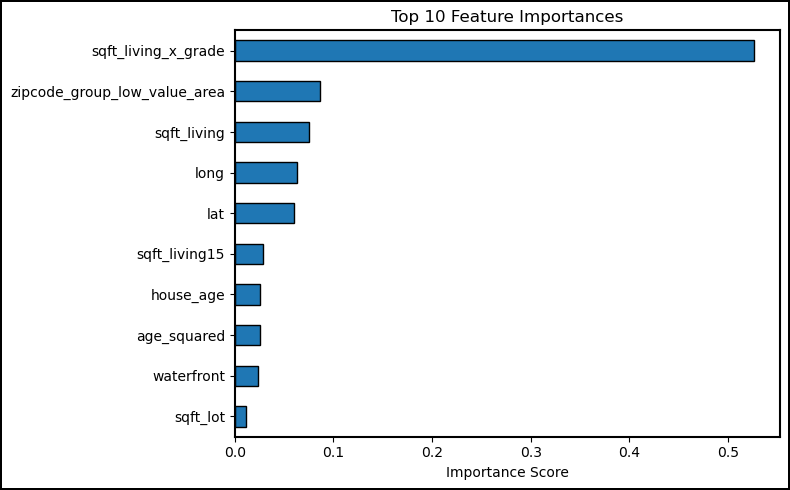

In [9]:
import matplotlib.pyplot as plt

# Get top 10 features
feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)
top_features = feat_imp.sort_values(ascending=False).head(10)

# Plot
fig, ax = plt.subplots(figsize=(8,5))

top_features.sort_values().plot(
    kind='barh',
    edgecolor='black',
    ax=ax
)

# Add black border around entire plot
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

# Optional: also add border around figure (outer frame)
fig.patch.set_edgecolor('black')
fig.patch.set_linewidth(1.5)

ax.set_title("Top 10 Feature Importances")
ax.set_xlabel("Importance Score")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

Tuning with Grid search "Engine" 

In [ ]:
"""""
param_grid = {
    'n_estimators': [200],
    'max_depth': [20,30],
    'min_samples_split': [2],
}

rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score: 0.8739426247865394


In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 72631.81477115431
RMSE: 146329.42233661885
R²: 0.8583624453679874


In [8]:
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print("MAPE:", mape, "%")

MAPE: 13.131485467990963 %


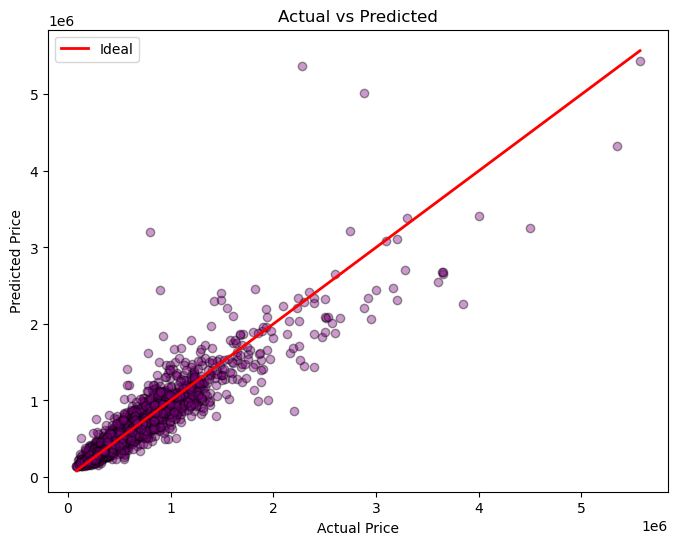

In [9]:

plt.figure(figsize=(8,6))

# Scatter plot (change color here)
plt.scatter(y_test, y_pred, alpha=0.4, color='purple', edgecolor='black')

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2, label='Ideal')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.legend()
plt.show()

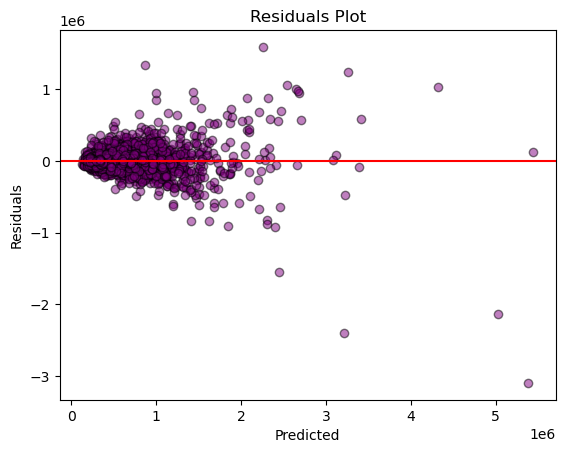

In [10]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, alpha=0.5,color='purple', edgecolor='black')
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals Plot")
plt.show()

Trying Regrressors: 

In [11]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,   
    reg_lambda=1.5,      
    random_state=42
)

model.fit(X_train, y_train)

print("Train R²:", model.score(X_train, y_train))
print("Test R²:", model.score(X_test, y_test))

Train R²: 0.961502445820382
Test R²: 0.8840933956668501


In [ ]:

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV


xgb = XGBRegressor(
    random_state=42,
    objective='reg:squarederror',
    n_jobs=-1 
)

param_grid = {
    "n_estimators": [100,200,300],
    "max_depth": [2,3,4],
    "learning_rate": [0.05],
    "subsample": [0.6,0.8],
    "colsample_bytree": [0.6,0.8],
    "reg_lambda" :[1.5,5,10],
    "reg_alpha": [0.1,1]
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

best_model = grid.best_estimator_

print("Train R²:", best_model.score(X_train, y_train))
print("Test R²:", best_model.score(X_test, y_test))

Fitting 3 folds for each of 216 candidates, totalling 648 fits


: 

##plot feature importance here

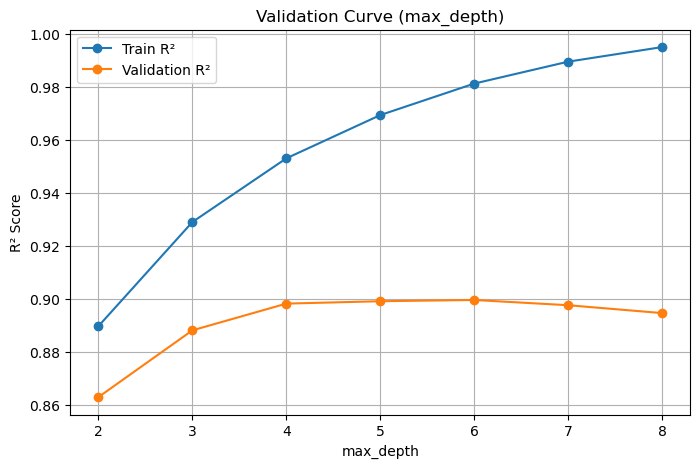

In [ ]:


# Define model (keep everything constant except max_depth)
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

param_range = [2, 3, 4, 5, 6, 7, 8]

train_scores, val_scores = validation_curve(
    model,
    X_train,
    y_train,
    param_name="max_depth",
    param_range=param_range,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

# Mean scores
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

# Plot
plt.figure(figsize=(8,5))
plt.plot(param_range, train_mean, label="Train R²", marker='o')
plt.plot(param_range, val_mean, label="Validation R²", marker='o')

plt.xlabel("max_depth")
plt.ylabel("R² Score")
plt.title("Validation Curve (max_depth)")
plt.legend()
plt.grid()
plt.show()